In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = pd.read_csv('C:/Users/MOUSSA/Desktop/FORMATIONS/Formation_PowerBI/Projet_performance-analysis/business-performance-analysis/data/processed/sales_data_clean.csv')
data.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,NaN,1618.5,3,20,32370.0,0.0,32370.0,16185.0,16185.0,2014-01-01,1,January,2014
1,Government,Germany,Carretera,NaN,1321.0,3,20,26420.0,0.0,26420.0,13210.0,13210.0,2014-01-01,1,January,2014
2,Midmarket,France,Carretera,NaN,2178.0,3,15,32670.0,0.0,32670.0,21780.0,10890.0,2014-06-01,6,June,2014
3,Midmarket,Germany,Carretera,NaN,888.0,3,15,13320.0,0.0,13320.0,8880.0,4440.0,2014-06-01,6,June,2014
4,Midmarket,Mexico,Carretera,NaN,2470.0,3,15,37050.0,0.0,37050.0,24700.0,12350.0,2014-06-01,6,June,2014


In [14]:
data[['Discount Band']].isnull().sum()

Discount Band    53
dtype: int64

In [22]:
data['Discount Band'] = data['Discount Band'].fillna('No Discount')

In [23]:
data[['Discount Band']].isnull().sum()

Discount Band    0
dtype: int64

In [24]:
data["discount_rate"] = (
    data["Discounts"] / data["Gross Sales"]
)

In [25]:
data["margin_rate"] = (
    data["Profit"] / data["Sales"]
)

### Description

In [26]:
data[[
    "Discount Band",
    "discount_rate",
    "Units Sold",
    "Sales",
    "Profit",
    "margin_rate"
]].describe().round(2)

,discount_rate,Units Sold,Sales,Profit,margin_rate
count,700.00,700.00,700.00,700.00,700.00
mean,0.07,1608.29,169609.07,24133.86,0.28
std,0.05,867.43,236726.35,42760.63,0.23
min,0.00,200.00,1655.08,-40617.50,-0.13
25%,0.03,905.00,15928.00,2805.96,0.13
50%,0.07,1542.50,35540.20,9242.20,0.23
75%,0.11,2229.12,261077.50,22662.00,0.43
max,0.15,4492.50,1159200.00,262200.00,0.75


In [29]:
volume_by_discount = (
    data.groupby("Discount Band")
.agg(avg_units_sold=("Units Sold", "mean"), 
    total_units_sold=("Units Sold", "sum"),
    avg_discount_rate=("discount_rate", "mean")
    )
)
volume_by_discount.round(2)

,avg_units_sold,total_units_sold,avg_discount_rate
Discount Band,,,
High,1624.84,398085.5,0.13
Low,1636.62,261858.5,0.02
Medium,1569.00,379698.5,0.07
No Discount,1625.73,86163.5,0.00


#### Comparer volume et rentabilité

In [34]:
discount_analysis = (
    data.groupby("Discount Band")
      .agg(
          avg_units=("Units Sold", "mean"),
          total_sales=("Sales", "sum"),
          total_profit=("Profit", "sum"),
          avg_margin=("margin_rate", "mean"),
          avg_discount_rate=("discount_rate", "mean")
      )
)
discount_analysis.columns = [
    "Avg Units Sold",
    "Chiffre d'Affaires",
    "Total Profit",
    "Avg Margin",
    "Avg Discount Rate"
]
round(discount_analysis, 2)

,Avg Units Sold,Chiffre d'Affaires,Total Profit,Avg Margin,Avg Discount Rate
Discount Band,,,,,
High,1624.84,37372486.72,3388866.72,0.24,0.13
Low,1636.62,34629778.70,6188857.70,0.29,0.02
Medium,1569.00,38780430.83,5579522.83,0.29,0.07
No Discount,1625.73,7943654.00,1736455.00,0.37,0.00


In [35]:
data.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year,discount_rate,margin_rate
0,Government,Canada,Carretera,No Discount,1618.5,3,20,32370.0,0.0,32370.0,16185.0,16185.0,2014-01-01,1,January,2014,0.0,0.500000
1,Government,Germany,Carretera,No Discount,1321.0,3,20,26420.0,0.0,26420.0,13210.0,13210.0,2014-01-01,1,January,2014,0.0,0.500000
2,Midmarket,France,Carretera,No Discount,2178.0,3,15,32670.0,0.0,32670.0,21780.0,10890.0,2014-06-01,6,June,2014,0.0,0.333333
3,Midmarket,Germany,Carretera,No Discount,888.0,3,15,13320.0,0.0,13320.0,8880.0,4440.0,2014-06-01,6,June,2014,0.0,0.333333
4,Midmarket,Mexico,Carretera,No Discount,2470.0,3,15,37050.0,0.0,37050.0,24700.0,12350.0,2014-06-01,6,June,2014,0.0,0.333333


#### Visualiser le compromis

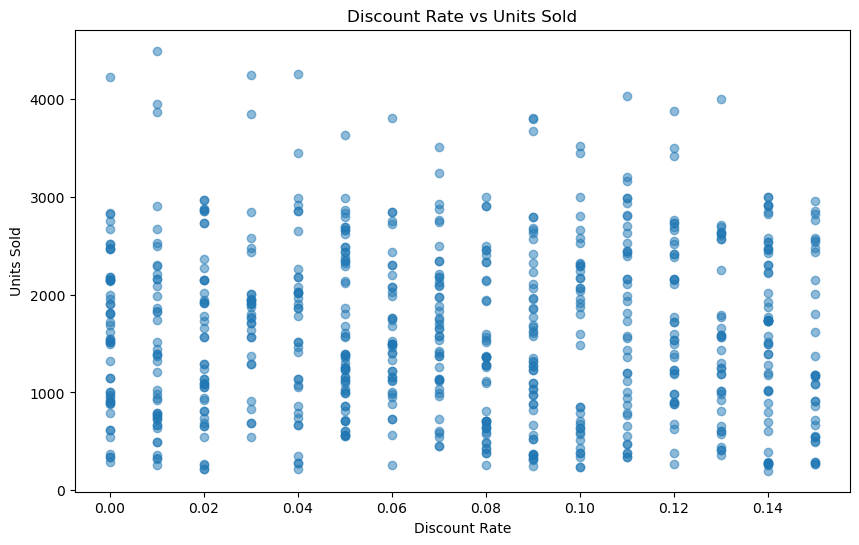

In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(
    data["discount_rate"],
    data["Units Sold"],
    alpha=0.5
)

plt.xlabel("Discount Rate")
plt.ylabel("Units Sold")
plt.title("Discount Rate vs Units Sold")
plt.show()

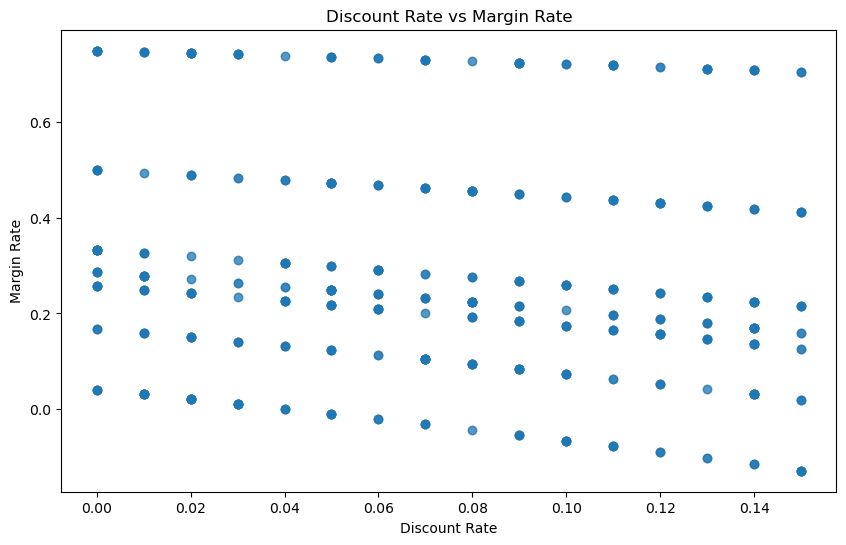

In [40]:
plt.figure(figsize=(10, 6))
plt.scatter(
    data["discount_rate"],
    data["margin_rate"],
    alpha=0.5
)

plt.xlabel("Discount Rate")
plt.ylabel("Margin Rate")
plt.title("Discount Rate vs Margin Rate")
plt.show()